<a href="https://colab.research.google.com/github/adeyemoadesola20-hash/cifar10-image-deployment./blob/main/week_5_NLP_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opendatasets
import opendatasets as od

# Download the Amazon Reviews dataset
od.download("https://www.kaggle.com/datasets/bittlingmayer/amazonreviews")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: adeyemoadesola
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/bittlingmayer/amazonreviews


100%|██████████| 493M/493M [00:07<00:00, 68.7MB/s]


In [ ]:
import pandas as pd
import bz2

# Function to parse the raw text file from Kaggle
def load_amazon_data(filename, num_lines=30000):
    labels = []
    texts = []
    with bz2.BZ2File(filename, 'rb') as f:
        for i, line in enumerate(f):
            if i >= num_lines:
                break
            line = line.decode('utf-8')
            # __label__1 is Negative (0), __label__2 is Positive (1)
            labels.append(1 if line.split()[0] == '__label__2' else 0)
            texts.append(' '.join(line.split()[1:]))
    return pd.DataFrame({'text': texts, 'sentiment': labels})

# Load the dataset using the path from your downloaded folder
df = load_amazon_data('amazonreviews/train.ft.txt.bz2', num_lines=30000)

# Look at the first 5 rows to confirm it worked
print(df.head())

                                                text  sentiment
0  Stuning even for the non-gamer: This sound tra...          1
1  The best soundtrack ever to anything.: I'm rea...          1
2  Amazing!: This soundtrack is my favorite music...          1
3  Excellent Soundtrack: I truly like this soundt...          1
4  Remember, Pull Your Jaw Off The Floor After He...          1


In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# 1. Download ALL necessary text components first (including the required punkt_tab)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# 2. Define stop words safely AFTER downloading them
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Convert text to lowercase
    text = text.lower()
    # Remove punctuation and special characters
    text = re.sub(r'[^\w\s]', '', text)
    # Tokenize text into words
    words = word_tokenize(text)
    # Remove stop words
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

# 3. Run the cleaning process over the dataframe
print("Cleaning text data... (This should take under a minute)")
df['clean_text'] = df['text'].apply(preprocess_text)
print("Text Preprocessing Complete!")

# Look at the result to confirm
print(df[['text', 'clean_text']].head(2))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Cleaning text data... (This should take under a minute)
Text Preprocessing Complete!
                                                text  \
0  Stuning even for the non-gamer: This sound tra...   
1  The best soundtrack ever to anything.: I'm rea...   

                                          clean_text  
0  stuning even nongamer sound track beautiful pa...  
1  best soundtrack ever anything im reading lot r...  


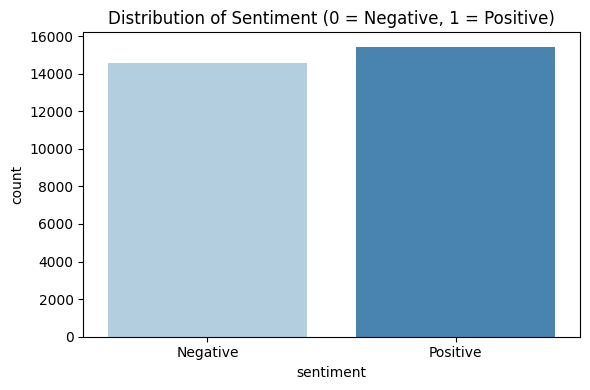

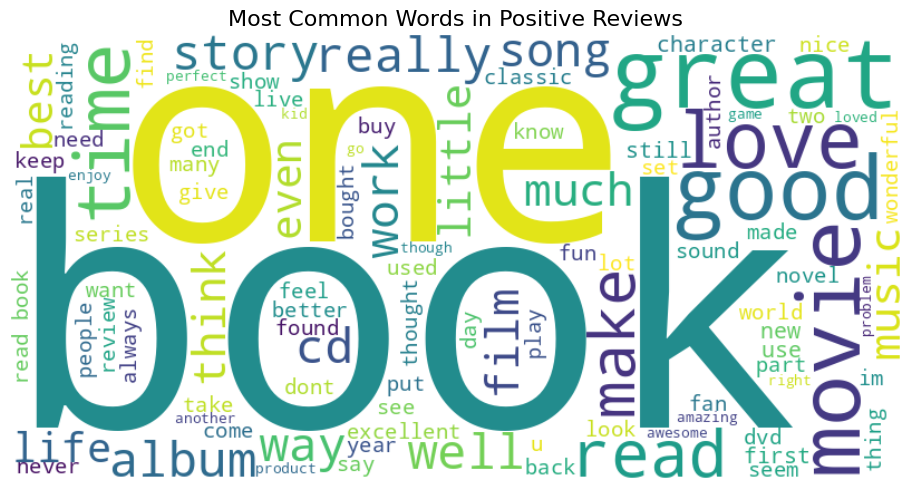

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# 1. Distribution of Sentiment Classes
plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment', data=df, hue='sentiment', palette='Blues', legend=False)
plt.title('Distribution of Sentiment (0 = Negative, 1 = Positive)')
plt.xticks([0, 1], ['Negative', 'Positive'])
plt.tight_layout()
plt.savefig('sentiment_distribution.png')  # Saves the chart to your files
plt.show()

# 2. Generate a Word Cloud for Positive Reviews
positive_reviews = ' '.join(df[df['sentiment'] == 1]['clean_text'])
wordcloud_pos = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(positive_reviews)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Positive Reviews', fontsize=16)
plt.tight_layout()
plt.savefig('positive_wordcloud.png')  # Saves the word cloud to your files
plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# --- Step 3: Text Vectorization (TF-IDF) ---
print("Vectorizing text data...")
# Initialize TF-IDF Vectorizer (limiting to top 5,000 words for speed and memory efficiency)
tfidf = TfidfVectorizer(max_features=5000)

# Transform our cleaned text into a numerical matrix
X = tfidf.fit_transform(df['clean_text'])
y = df['sentiment'].values

# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Vectorization complete! Feature matrix shape: {X.shape}")

# --- Step 4: Sentiment Analysis Model Training ---
print("Training Logistic Regression model...")
# Initialize and train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Generate predictions on our test data
y_pred = model.predict(X_test)
print("Model Training Complete!")

Vectorizing text data...
Vectorization complete! Feature matrix shape: (30000, 5000)
Training Logistic Regression model...
Model Training Complete!


Overall Model Accuracy: 87.17%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.86      0.87      2930
    Positive       0.87      0.88      0.88      3070

    accuracy                           0.87      6000
   macro avg       0.87      0.87      0.87      6000
weighted avg       0.87      0.87      0.87      6000



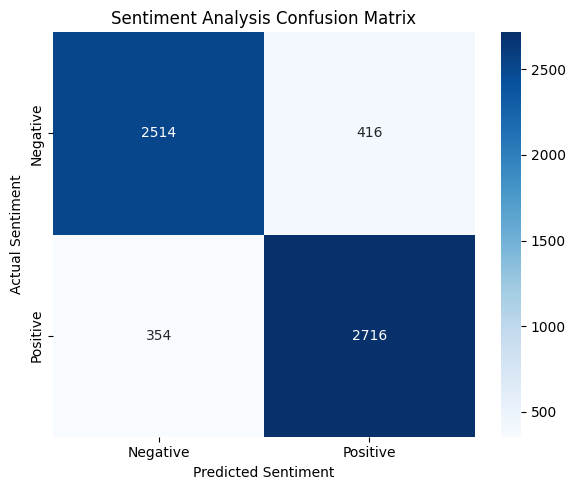

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Calculate and Print Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Model Accuracy: {accuracy * 100:.2f}%\n")

# 2. Print Detailed Classification Report (Precision, Recall, F1-Score)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# 3. Generate and Save the Confusion Matrix Visual
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.ylabel('Actual Sentiment')
plt.xlabel('Predicted Sentiment')
plt.title('Sentiment Analysis Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png')  # Saves the image to your file manager
plt.show()